# ТЗ
Реализация стохастических градиентных методов с $AdaGrad$ и $AdamW$.
Подходы к борьбе с переобучением:
- Отложенная выборка (Hold-out Validation): Техника однократного разбиения исходного множества на изолированные подмножества. Если тестовое подмножество используется исключительно для финальной фиксации метрик качества, процедура корректна. Если же по отложенной выборке подбираются гиперпараметры ($\lambda$) или принимается решение о досрочной остановке (Early Stopping), для предотвращения утечки данных (data leakage) обычно применяется трехкомпонентное разбиение: Train (настройка весов), Validation (оптимизация $\lambda$, Early Stopping) и Test.
- L1-регуляризация (аппроксимация Lasso штрафа):$$J_{L1} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^M |w_j|$$
- L2-регуляризация (Ridge-штраф):$$J_{L2} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^M w_j^2$$

где $B$ - размер текущего батча, $M$ - количество признаков, а вектор весов $w$ не включает в себя свободный член (bias).

*Разъяснение по AdamW: для AdamW регуляризация не добавляется в функционал ошибки $J_{L2}$, а реализуется через механизм расцепленного спада весов (Decoupled Weight Decay) непосредственно на этапе обновления параметров (что изолирует адаптивный шаг обучения от влияния градиентов L2-нормы)*:
$$w_{t+1} = w_t - \eta \lambda w_t - \text{Adam}(\nabla_w J_{MSE})$$

# Импорт библиотек, датасета, hold-out validation

In [1]:
import copy
import itertools
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CONFIG = {
    "EPOCHS": 500,                       
    "BATCH_SIZE": 64,                      
    "LEARNING_RATES": [0.001, 0.01, 0.05, 0.1],   
    "LAMBDAS": [], # Падает до 0, если reg == None
    "REG_TYPES": ["L1", "L2", "None"],
    "OPTIMIZERS": ["AdaGrad", "AdamW"],
    "SEED": 67,
}

In [3]:
# Находим нужный сэмплированный датасет
target_relative_path = Path("..") / "Dataset (Farhat)" / "dataset_sample_1000.csv"
dataset_path = target_relative_path.resolve()

if not dataset_path.exists():
    raise FileNotFoundError(f"ОШИБКА: файл датасета не найден по пути: {dataset_path}")
print(f"Успешно обнаружен файл датасета по пути: {dataset_path}")

Успешно обнаружен файл датасета по пути: /Users/test/Desktop/Various_Linear_Regression_Factors/Dataset (Farhat)/dataset_sample_1000.csv


In [4]:
# устанавливаем сиды для воспроизводимости эксперимента
torch.manual_seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])

df = pd.read_csv(dataset_path)

target_col = 'Log_Цена'

X_raw = df.drop(columns=[target_col]).values
y_raw = df[target_col].values.reshape(-1, 1)
# 80/20 - train/test
X_train_val_raw, X_test_raw, y_train_val_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=CONFIG["SEED"]
)
# 60/20 - train/validation  
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_val_raw, y_train_val_raw, test_size=0.25, random_state=CONFIG["SEED"]
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_val_scaled = scaler_X.transform(X_val_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# MINI-BACTH
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)

# Сетка параметров
CONFIG["LAMBDAS"] = np.logspace(-4,-1,num=4)
INPUT_DIM = X_train_tensor.shape[1]  # количество фич

# Структура для логирования кривых обучения
history_data = {}

print(f"Train фичи: {X_train_tensor.shape}, таргет: {y_train_tensor.shape}")
print(f"Val   фичи: {X_val_tensor.shape}, таргет: {y_val_tensor.shape}")
print(f"Test  фичи: {X_test_tensor.shape}, таргет: {y_test_tensor.shape}")

Train фичи: torch.Size([600, 20]), таргет: torch.Size([600, 1])
Val   фичи: torch.Size([200, 20]), таргет: torch.Size([200, 1])
Test  фичи: torch.Size([200, 20]), таргет: torch.Size([200, 1])


# Построение baselines 

## Обычное среднее (стандартизированное)

In [5]:
mean_train_pred = np.full_like(y_train_scaled, np.mean(y_train_scaled))
mean_test_pred = np.full_like(y_test_scaled, np.mean(y_train_scaled))

mse_mean_train = mean_squared_error(y_train_scaled, mean_train_pred)
mse_mean_test = mean_squared_error(y_test_scaled, mean_test_pred)
history_data["Baseline_Mean"] = {
    "train": [mse_mean_train] * CONFIG["EPOCHS"],
    "test": [mse_mean_test] * CONFIG["EPOCHS"],
    "final_test": mse_mean_test
}

## МНК (без, с L1, L2 регуляризациями)

In [6]:
# МНК без регуляризаций:
ols_pure = LinearRegression().fit(X_train_scaled, y_train_scaled)
mse_ols_train = mean_squared_error(y_train_scaled, ols_pure.predict(X_train_scaled))
mse_ols_test = mean_squared_error(y_test_scaled, ols_pure.predict(X_test_scaled))
history_data["Baseline_OLS_Pure"] = {
    "train": [mse_ols_train] * CONFIG["EPOCHS"],
    "test": [mse_ols_test] * CONFIG["EPOCHS"],
    "final_test": mse_ols_test
}

# МНК с регуляризациями 
for lmbda in CONFIG["LAMBDAS"]:
    # L1 (Lasso) 
    lasso = Lasso(alpha=lmbda, max_iter=10000).fit(X_train_scaled, y_train_scaled)
    mse_l1_train = mean_squared_error(y_train_scaled, lasso.predict(X_train_scaled).reshape(-1, 1))
    mse_l1_test = mean_squared_error(y_test_scaled, lasso.predict(X_test_scaled).reshape(-1, 1))
    history_data[f"Baseline_OLS_L1_lambda_{lmbda:.4f}"] = {
        "train": [mse_l1_train] * CONFIG["EPOCHS"],
        "test": [mse_l1_test] * CONFIG["EPOCHS"],
        "final_test": mse_l1_test
    }
    
    # L2 (Ridge)
    ridge = Ridge(alpha=lmbda).fit(X_train_scaled, y_train_scaled)
    mse_l2_train = mean_squared_error(y_train_scaled, ridge.predict(X_train_scaled))
    mse_l2_test = mean_squared_error(y_test_scaled, ridge.predict(X_test_scaled))
    history_data[f"Baseline_OLS_L2_lambda_{lmbda:.4f}"] = {
        "train": [mse_l2_train] * CONFIG["EPOCHS"],
        "test": [mse_l2_test] * CONFIG["EPOCHS"],
        "final_test": mse_l2_test
    }

# Использование оптимизаторов (библиотечное)

## *AdaGrad* (Adaptive Gradient Algorithm)
- Суть: Алгоритм адаптирует темп обучения покоординатно, масштабируя текущий градиент обратно пропорционально корню из суммы квадратов всех исторических градиентов данного параметра. Это позволяет делать большие шаги по редким (разреженным) признакам и уменьшать шаг по часто обновляемым.

Математический шаг оптимизации:
Пусть $g_t = \nabla_{\theta} L(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$. Аккумуляция квадратов градиентов $G_t \in \mathbb{R}^d$ и обновление параметров выполняются покоординатно (оператор $\odot$ обозначает умножение Адамара):
$$ G_t = G_{t-1} + g_t \odot g_t $$
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t $$
Где $\eta$ - базовый темп обучения, а $\epsilon > 0$ - сглаживающий параметр, предотвращающий деление на ноль (в реализации torch.optim.Adagrad по умолчанию $\epsilon = 10^{-10}$). Монотонное возрастание компонент вектора $G_t$ гарантирует монотонное убывание эффективного шага.

## AdamW (Adam with Decoupled Weight Decay)
- Суть: модификация классического алгоритма Adam, которая изолирует (расцепляет) механизм регуляризации от процесса адаптации темпа обучения. Adam комбинирует идеи накопления импульса (Momentum) и покоординатного масштабирования шага (RMSProp), вычисляя экспоненциально затухающие средние прошлых градиентов ($m_t$) и их квадратов ($v_t$). В отличие от Adam, где L2-штраф модифицирует градиент, AdamW выполняет спад весов (Weight Decay) напрямую на этапе обновления параметров.

Математический шаг оптимизации: Пусть $g_t = \nabla_{\theta} L_{MSE}(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$, рассчитанный без учета регуляризационных штрафов.
Вычисление смещенных оценок первого (усредненный градиент) и второго (нецентрированная дисперсия) моментов:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t$$
Коррекция смещения моментов для компенсации инициализации нулями ($m_0 = 0, v_0 = 0$):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
Модификация шага параметров и финальное обновление (механизм Decoupled Weight Decay):
$$\theta_{t+1} = \theta_t \cdot (1 - \eta \lambda) - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

где:
$\eta$ - базовый темп обучения (lr);
$\lambda$ - коэффициент спада весов (weight_decay);
$\beta_1, \beta_2$ - коэффициенты затухания моментов (канонические значения: $\beta_1=0.9, \beta_2=0.999$);
$\epsilon$ - сглаживающий параметр для численной стабильности (в torch.optim.AdamW по умолчанию $\epsilon = 10^{-8}$).

- Отличие от классического Adam: если в обычном Adam использовать параметр weight_decay, алгоритм преобразует градиент: $g^{new}_t = g_t + \lambda \theta_t$. В этом случае штраф "подмешивается" в моменты $m_t$ и $v_t$. Из-за деления на $\sqrt{v_t}$ в адаптивном шаге веса, которые исторически имели большие градиенты, будут штрафоваться меньше, чем веса с маленькими градиентами. AdamW решает данную проблему, выполняя линейный спад веса $\theta_t \cdot (1 - \eta \lambda)$ независимо от накопленной динамики градиентов.

In [10]:
keys = ["opt", "reg", "lr"]
combinations = itertools.product(
    CONFIG["OPTIMIZERS"],
    CONFIG["REG_TYPES"],
    CONFIG["LEARNING_RATES"]
)
configurations = [dict(zip(keys, comb)) for comb in combinations]
for config in configurations:
    opt_name = config["opt"]
    reg_type = config["reg"]
    learning_rate = config["lr"]
    
    lambdas_to_run = [0.0] if reg_type == "None" else CONFIG["LAMBDAS"]
    
    for lmbda in lambdas_to_run:
        torch.manual_seed(CONFIG["SEED"])
        model = nn.Linear(INPUT_DIM, 1)
        criterion = nn.MSELoss()
        
        wd_param = lmbda if (reg_type == "L2" and opt_name == "AdamW") else 0.0
        
        decay_params = []
        no_decay_params = []
        for name, param in model.named_parameters():
            if 'bias' in name:
                no_decay_params.append(param)
            else:
                decay_params.append(param)
                
        optimizer_grouped_parameters = [
            {'params': decay_params, 'weight_decay': wd_param},
            {'params': no_decay_params, 'weight_decay': 0.0}
        ]
        
        if opt_name == "AdaGrad":
            optimizer = optim.Adagrad(optimizer_grouped_parameters, lr=learning_rate)
        elif opt_name == "AdamW":
            optimizer = optim.AdamW(optimizer_grouped_parameters, lr=learning_rate)
            
        train_epochs_loss = []
        val_epochs_loss = []
        test_epochs_loss = [] 

        start_time = time.time()
        best_val_mse = float("inf")
        best_test_mse_at_best_val = float("inf") 
        best_model_state = None
        
        for epoch in range(CONFIG["EPOCHS"]):
            model.train()
            for batch_X, batch_y in train_loader:
                optimizer.zero_grad(set_to_none=True)
                predictions = model(batch_X)
                
                loss = criterion(predictions, batch_y)
                
                if reg_type == "L1":
                    loss += lmbda * model.weight.abs().sum()
                elif reg_type == "L2" and opt_name == "AdaGrad":
                    loss += (lmbda / 2) * model.weight.pow(2.0).sum()
                    
                loss.backward()
                optimizer.step()
                
            model.eval()
            with torch.no_grad():
                current_train_mse = criterion(model(X_train_tensor), y_train_tensor).item()
                current_val_mse = criterion(model(X_val_tensor), y_val_tensor).item()
                current_test_mse = criterion(model(X_test_tensor), y_test_tensor).item()
                
            train_epochs_loss.append(current_train_mse)
            val_epochs_loss.append(current_val_mse)
            test_epochs_loss.append(current_test_mse)
            
            if current_val_mse < best_val_mse:
                best_val_mse = current_val_mse
                best_test_mse_at_best_val = current_test_mse 
                best_model_state = copy.deepcopy(model.state_dict())
        
        elapsed_time = time.time() - start_time
        
        if reg_type == "None":
            exp_key = f"{opt_name}_None_lr_{learning_rate}"
        else:
            exp_key = f"{opt_name}_{reg_type}_lr_{learning_rate}_lambda_{lmbda:.4f}"
            
        history_data[exp_key] = {
            "train": train_epochs_loss,
            "val": val_epochs_loss,
            "test": test_epochs_loss,
            "final_test": test_epochs_loss[-1], 
            "time": elapsed_time,
            "best_val_mse": best_val_mse,
            "best_mse": best_test_mse_at_best_val,
            "best_state": best_model_state,
            "lr": learning_rate,    
            "opt": opt_name,
            "reg": reg_type,
            "lmbda": lmbda
        }

# Графики MSE/CONFIG["EPOCHS"]

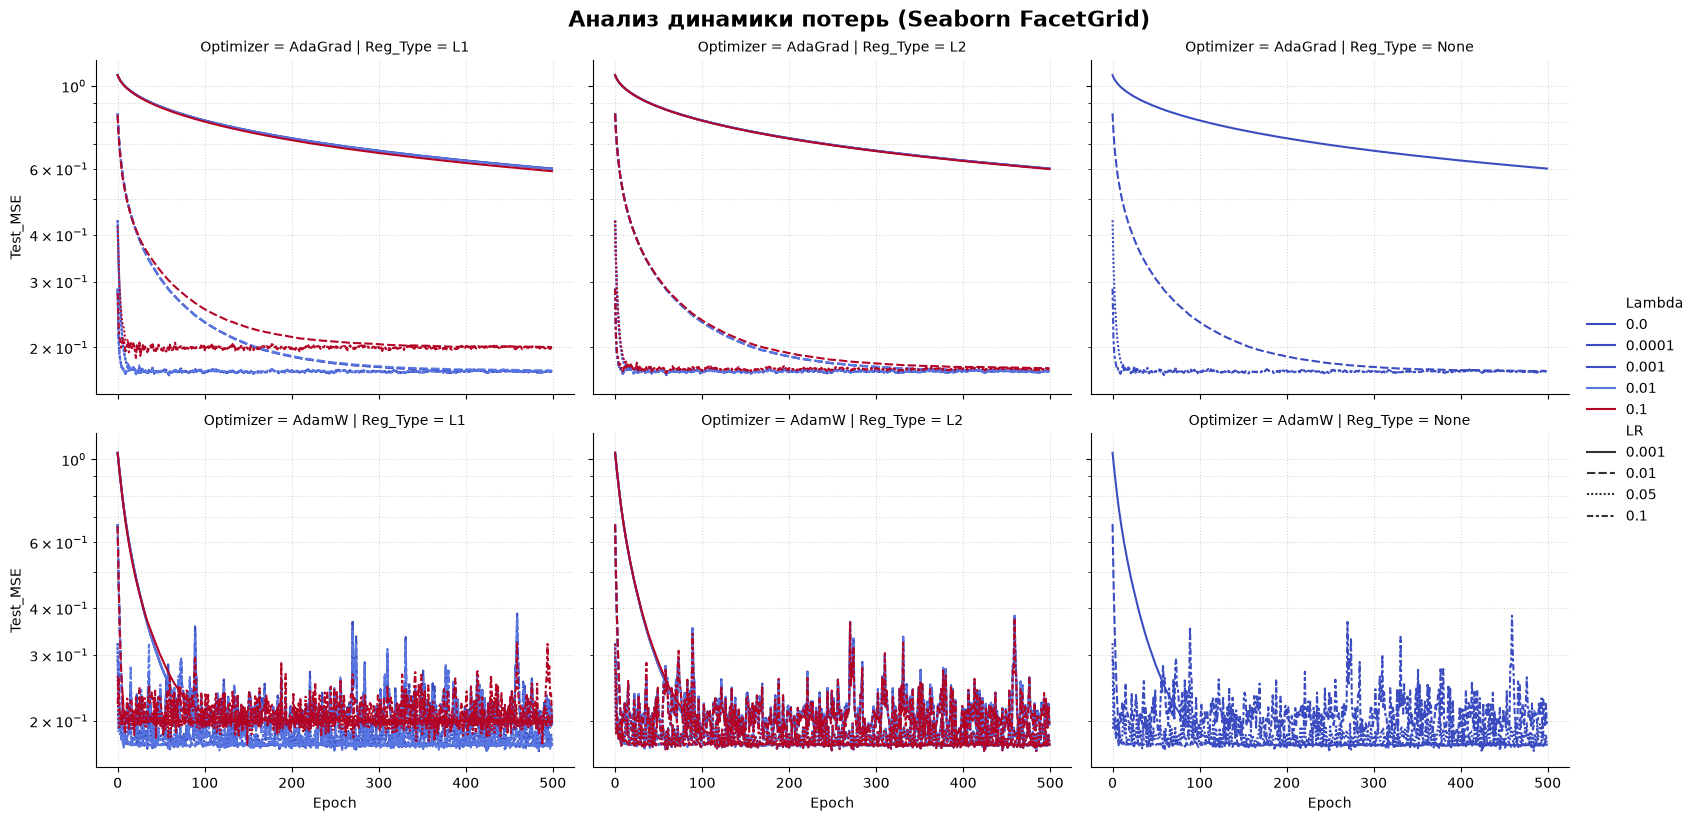

In [11]:
history_records = []
for key, value in history_data.items():
    if "lr" in value: 
        for epoch in range(CONFIG["EPOCHS"]):
            history_records.append({
                "Optimizer": value["opt"],
                "Reg_Type": value["reg"],
                "LR": value["lr"],
                "Lambda": float(key.split("_lambda_")[1]) if "lambda_" in key else 0.0,
                "Epoch": epoch,
                "Train_MSE": value["train"][epoch],
                "Test_MSE": value["test"][epoch]
            })

df_history = pd.DataFrame(history_records)

g = sns.relplot(
    data=df_history,
    x="Epoch", 
    y="Test_MSE",
    hue="Lambda",      
    style="LR",          
    row="Optimizer",     
    col="Reg_Type",      
    kind="line",
    palette="coolwarm",     
    height=4, 
    aspect=1.3
)

for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

g.fig.suptitle("Анализ динамики потерь (Seaborn FacetGrid)", y=1.02, fontweight="bold", fontsize=16)
plt.show()

In [13]:
best_nn_models = {}
y_test_flat = y_test_scaled.flatten()

for opt in CONFIG["OPTIMIZERS"]:
    min_mse = float("inf")
    best_optimizer = None
    best_key = None
    
    # поиск минимального MSE среди всех регуляризаций и гиперпараметров для текущего оптимайзера
    for key, data in history_data.items():
        if data.get("opt") == opt and "best_mse" in data:
            if data["best_mse"] < min_mse:
                min_mse = data["best_mse"]
                best_optimizer = data["reg"]
                best_key = key
                
    if best_key:
        best_state = history_data[best_key]["best_state"]
        model = nn.Linear(INPUT_DIM, 1)
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = model(X_test_tensor).numpy().flatten()
        r2 = r2_score(y_test_flat, preds)
    else:
        r2 = None
                
    best_nn_models[opt] = {
        "best_optimizer": best_optimizer,
        "best_mse": min_mse,
        "best_key": best_key,
        "r2": r2
    }

print(f"{'~'*35}\nВЫБОР НАИЛУЧШИХ РЕГУЛЯРИЗАЦИЙ (best_optimizer):\n{'~'*35}")
for opt, meta in best_nn_models.items():
    print(f"Оптимизатор: {opt:<7} | Лучший тип (best_optimizer): {meta['best_optimizer']:<4} | Test MSE: {meta['best_mse']:.5f} | Test R2: {meta['r2']:.4f}")

# определяем глобальные переменные для следующей ячейки анализа остатков
absolute_best_opt = min(best_nn_models, key=lambda o: best_nn_models[o]["best_mse"])
absolute_best_reg = best_nn_models[absolute_best_opt]["best_optimizer"]
print(f"\nЛучшая модель: {absolute_best_opt} ({absolute_best_reg})\n{'~'*75}")

# извлечение данных Baseline Mean и расчет его R2 на тест-выборке
mean_mse = history_data["Baseline_Mean"]["final_test"]
mean_preds = np.full_like(y_test_flat, np.mean(y_train_scaled))
mean_r2 = r2_score(y_test_flat, mean_preds)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ВЫБОР НАИЛУЧШИХ РЕГУЛЯРИЗАЦИЙ (best_optimizer):
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Оптимизатор: AdaGrad | Лучший тип (best_optimizer): L1   | Test MSE: 0.17010 | Test R2: 0.8238
Оптимизатор: AdamW   | Лучший тип (best_optimizer): L1   | Test MSE: 0.16861 | Test R2: 0.8254

Лучшая модель: AdamW (L1)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


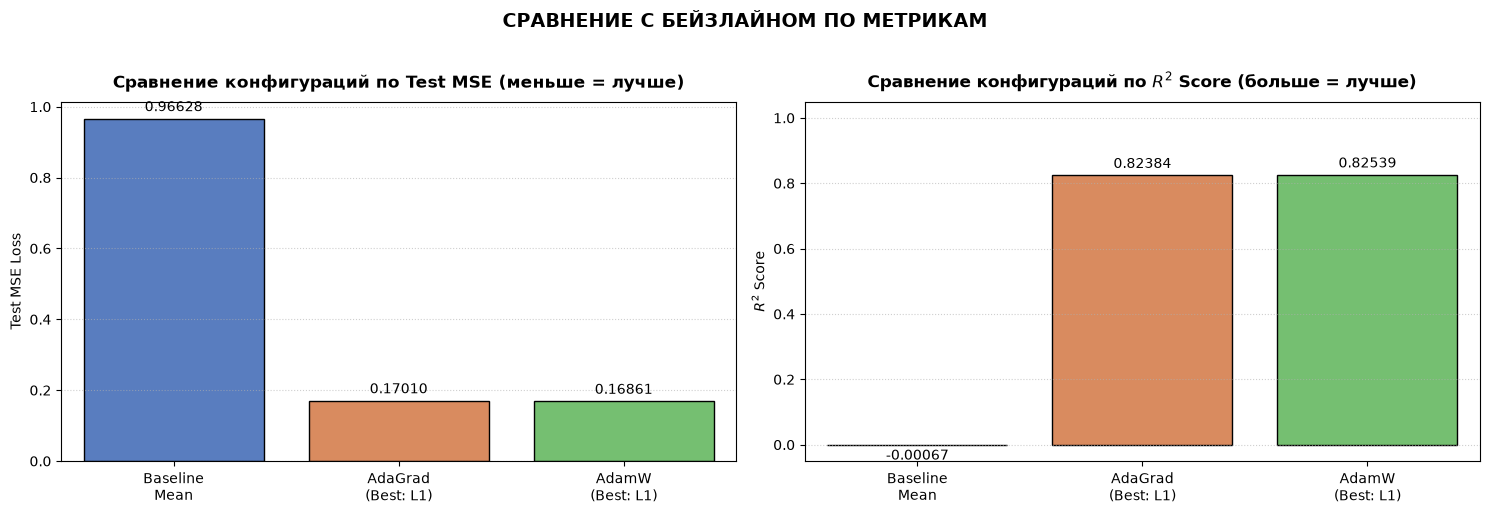

In [14]:
df_compare = pd.DataFrame([
    {"Config": "Baseline\nMean", "MSE": mean_mse, "R2": mean_r2}
] + [
    {
        "Config": f"{opt}\n(Best: {meta['best_optimizer']})", 
        "MSE": meta["best_mse"], 
        "R2": meta["r2"]
    }
    for opt, meta in best_nn_models.items()
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ЛЕВЫЙ ГРАФИК Сравнение по MSE
sns.barplot(
    data=df_compare, 
    x="Config", 
    y="MSE", 
    hue="Config", 
    palette="muted", 
    edgecolor="black", 
    legend=False,
    ax=ax1
)
ax1.set_title("Сравнение конфигураций по Test MSE (меньше = лучше)", fontweight="bold", fontsize=12, pad=10)
ax1.set_ylabel("Test MSE Loss")
ax1.set_xlabel("")
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fmt='%.5f')
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# ПРАВЫЙ ГРАФИК Сравнение по R^2
sns.barplot(
    data=df_compare, 
    x="Config", 
    y="R2", 
    hue="Config", 
    palette="muted", 
    edgecolor="black", 
    legend=False,
    ax=ax2
)
ax2.set_title("Сравнение конфигураций по $R^2$ Score (больше = лучше)", fontweight="bold", fontsize=12, pad=10)
ax2.set_ylabel("$R^2$ Score")
ax2.set_xlabel("")
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fmt='%.5f')
ax2.grid(axis='y', linestyle=':', alpha=0.6)
ax2.set_ylim(min(df_compare["R2"].min() * 1.15, -0.05), max(df_compare["R2"].max() * 1.15, 1.05))

plt.suptitle("СРАВНЕНИЕ С БЕЙЗЛАЙНОМ ПО МЕТРИКАМ", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# HEATMAP

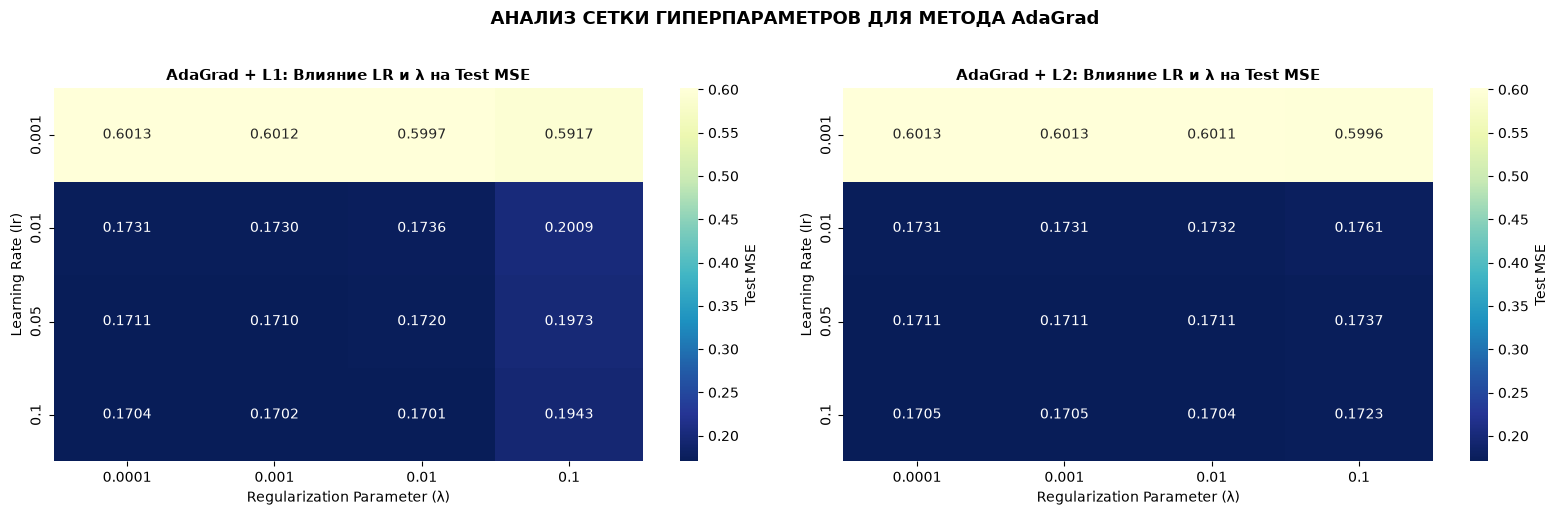

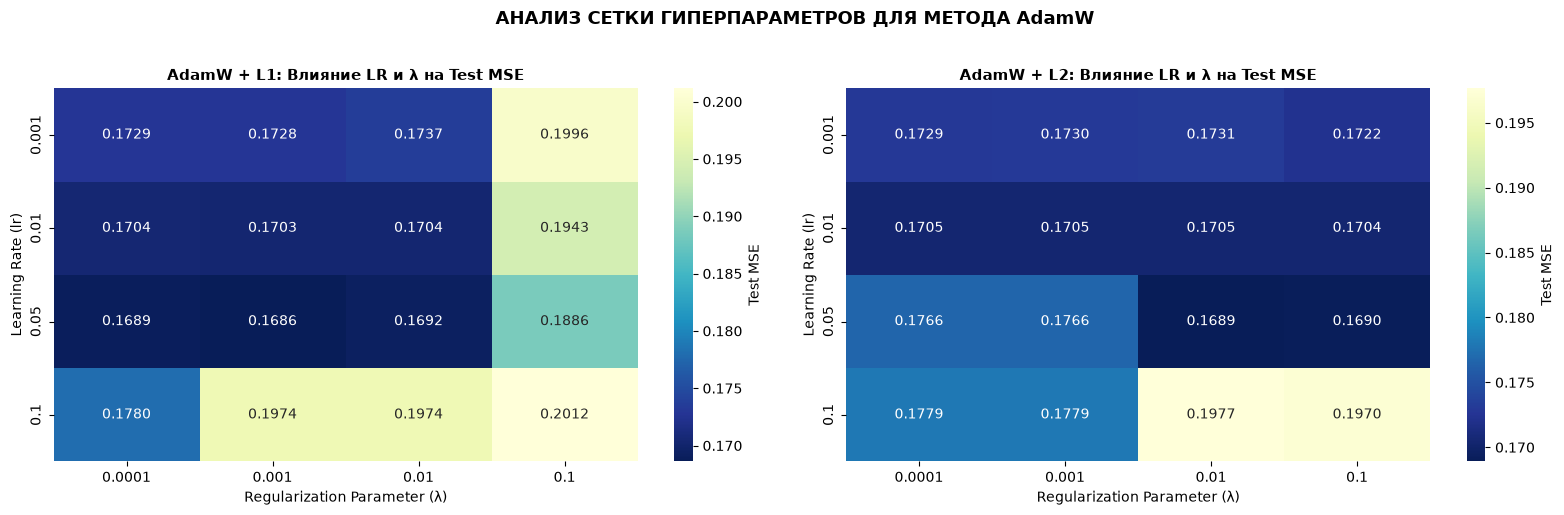

In [15]:
records = []
for key, value in history_data.items():
    if "lr" in value:  
        records.append({
            "Optimizer": value["opt"],
            "Reg_Type": value["reg"],
            "LR": value["lr"],
            "Lambda": float(key.split("_lambda_")[1]) if "lambda_" in key else 0.0,
            "Test_MSE": value["best_mse"]
        })

df_grid = pd.DataFrame(records)
# тепловые карты влияния гиперпараметров
for opt in CONFIG["OPTIMIZERS"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for idx, reg in enumerate(["L1", "L2"]):
        # Выбираем подвыборку для конкретного оптимизатора и регуляризации
        df_sub = df_grid[(df_grid["Optimizer"] == opt) & (df_grid["Reg_Type"] == reg)]
        pivot_df = df_sub.pivot(index="LR", columns="Lambda", values="Test_MSE")
        
        ax = axes[idx]
        sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=ax, cbar_kws={'label': 'Test MSE'})
        ax.set_title(f"{opt} + {reg}: Влияние LR и λ на Test MSE", fontweight='bold', fontsize=11)
        ax.set_ylabel("Learning Rate (lr)")
        ax.set_xlabel("Regularization Parameter (λ)")
        
    plt.suptitle(f"АНАЛИЗ СЕТКИ ГИПЕРПАРАМЕТРОВ ДЛЯ МЕТОДА {opt}", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Выбор best ols

In [17]:
def mape_score(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape_score(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

def to_original_scale(y_scaled, scaler):
    y_2d = y_scaled.reshape(-1, 1)
    y_unscaled = scaler.inverse_transform(y_2d)
    return np.expm1(y_unscaled).flatten()

def evaluate_model_all_scales(y_pred_scaled, y_true_scaled, y_true_original, scaler_y, num_features, zeroed_count=0):
    mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
    r2 = r2_score(y_true_scaled, y_pred_scaled)
    
    n_samples = len(y_true_scaled)
    active_features = num_features - zeroed_count
    denom = (n_samples - active_features - 1)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / denom if denom > 0 else r2

    y_pred_scaled_reshaped = np.array(y_pred_scaled).reshape(-1, 1)
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled_reshaped).flatten()
    
    y_pred_original = np.expm1(y_pred_log)

    mse_original = mean_squared_error(y_true_original, y_pred_original)
    rmse_original = np.sqrt(mse_original)
    mae_original = mean_absolute_error(y_true_original, y_pred_original)

    return {
        "MSE": mse_scaled,       
        "R2": r2,                
        "Adj_R2_scaled": adj_r2,
        "MSE_original": mse_original,
        "RMSE_original": rmse_original,
        "MAE_original": mae_original
    }

# Подгонка истинных значений
y_test_scaled_flat = y_test_scaled.flatten()
y_test_original = to_original_scale(y_test_scaled_flat, scaler_y)

ols_metrics = {}
n_samples = X_test_scaled.shape[0]
p_features = X_test_scaled.shape[1]

mean_pred_scaled = np.full_like(y_test_scaled_flat, np.mean(y_train_scaled))
ols_metrics["Mean_Baseline"] = evaluate_model_all_scales(
    mean_pred_scaled, y_test_scaled_flat, y_test_original, scaler_y, 1, 0
)

ols_pure = LinearRegression().fit(X_train_scaled, y_train_scaled)
ols_metrics["OLS_Pure"] = evaluate_model_all_scales(
    ols_pure.predict(X_test_scaled).flatten(), y_test_scaled_flat, y_test_original, scaler_y, p_features, 0
)

# МНК Lasso (L1) - поиск лучшей модели по ВАЛИДАЦИИ
best_lasso_val_mse = float("inf")
best_lasso_model = None

for lmbda in CONFIG["LAMBDAS"]:
    lasso = Lasso(alpha=lmbda, max_iter=10000).fit(X_train_scaled, y_train_scaled)
    val_pred = lasso.predict(X_val_scaled)
    val_mse = mean_squared_error(y_val_scaled.flatten(), val_pred.flatten())
    if val_mse < best_lasso_val_mse:
        best_lasso_val_mse = val_mse
        best_lasso_model = lasso

best_lasso_pred = best_lasso_model.predict(X_test_scaled)
best_lasso_zeroed = np.sum(best_lasso_model.coef_ == 0)
ols_metrics["OLS_Lasso"] = evaluate_model_all_scales(
    best_lasso_pred, y_test_scaled_flat, y_test_original, scaler_y, p_features, best_lasso_zeroed
)

# МНК Ridge (L2)
best_ridge_val_mse = float("inf")
best_ridge_model = None

for lmbda in CONFIG["LAMBDAS"]:
    ridge = Ridge(alpha=lmbda).fit(X_train_scaled, y_train_scaled)
    val_pred = ridge.predict(X_val_scaled)
    val_mse = mean_squared_error(y_val_scaled.flatten(), val_pred.flatten())
    if val_mse < best_ridge_val_mse:
        best_ridge_val_mse = val_mse
        best_ridge_model = ridge

best_ridge_pred = best_ridge_model.predict(X_test_scaled).flatten()
ols_metrics["OLS_Ridge"] = evaluate_model_all_scales(
    best_ridge_pred, y_test_scaled_flat, y_test_original, scaler_y, p_features, 0
)

# Выбор лучшей модели по логарифмическому MSE
models_keys = [k for k in ols_metrics.keys() if k != "Mean_Baseline"]
best_ols_model = min(models_keys, key=lambda m: ols_metrics[m]["MSE"])
print(f"{'~'*25}\nНаилучшая модель: {best_ols_model} с ошибкой {ols_metrics[best_ols_model]['MSE']:.6f}\n{'~'*25}")

~~~~~~~~~~~~~~~~~~~~~~~~~
Наилучшая модель: OLS_Ridge с ошибкой 0.172350
~~~~~~~~~~~~~~~~~~~~~~~~~


## Визуализация среднего + вариаций МНК

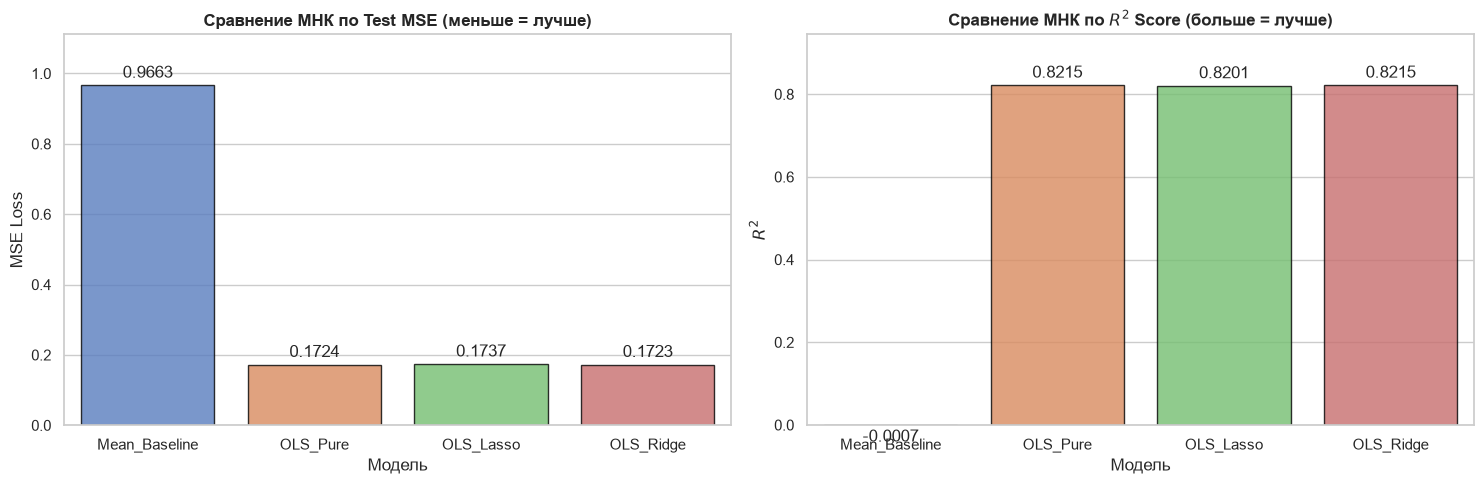

In [18]:
df_ols = pd.DataFrame.from_dict(ols_metrics, orient='index').reset_index()
df_ols = df_ols.rename(columns={'index': 'Model'})

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df_ols, x="Model", y="MSE", hue="Model", ax=ax1, palette="muted", edgecolor='black', alpha=0.8, legend=False)
ax1.set_title("Сравнение МНК по Test MSE (меньше = лучше)", fontweight='bold', fontsize=12)
ax1.set_ylabel("MSE Loss")
ax1.set_xlabel("Модель")
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fmt='%.4f') 

sns.barplot(data=df_ols, x="Model", y="R2", hue="Model", ax=ax2, palette="muted", edgecolor='black', alpha=0.8, legend=False)
ax2.set_title("Сравнение МНК по $R^2$ Score (больше = лучше)", fontweight='bold', fontsize=12)
ax2.set_ylabel("$R^2$")
ax2.set_xlabel("Модель")
for container in ax2.containers:
    ax2.bar_label(container, padding=3, fmt='%.4f')

ax1.set_ylim(0, df_ols["MSE"].max() * 1.15)
ax2.set_ylim(min(df_ols["R2"].min() * 1.15, 0), df_ols["R2"].max() * 1.15)

plt.tight_layout()
plt.show()

# Сравнение AdaGrad, AdamW с бейзлайнами

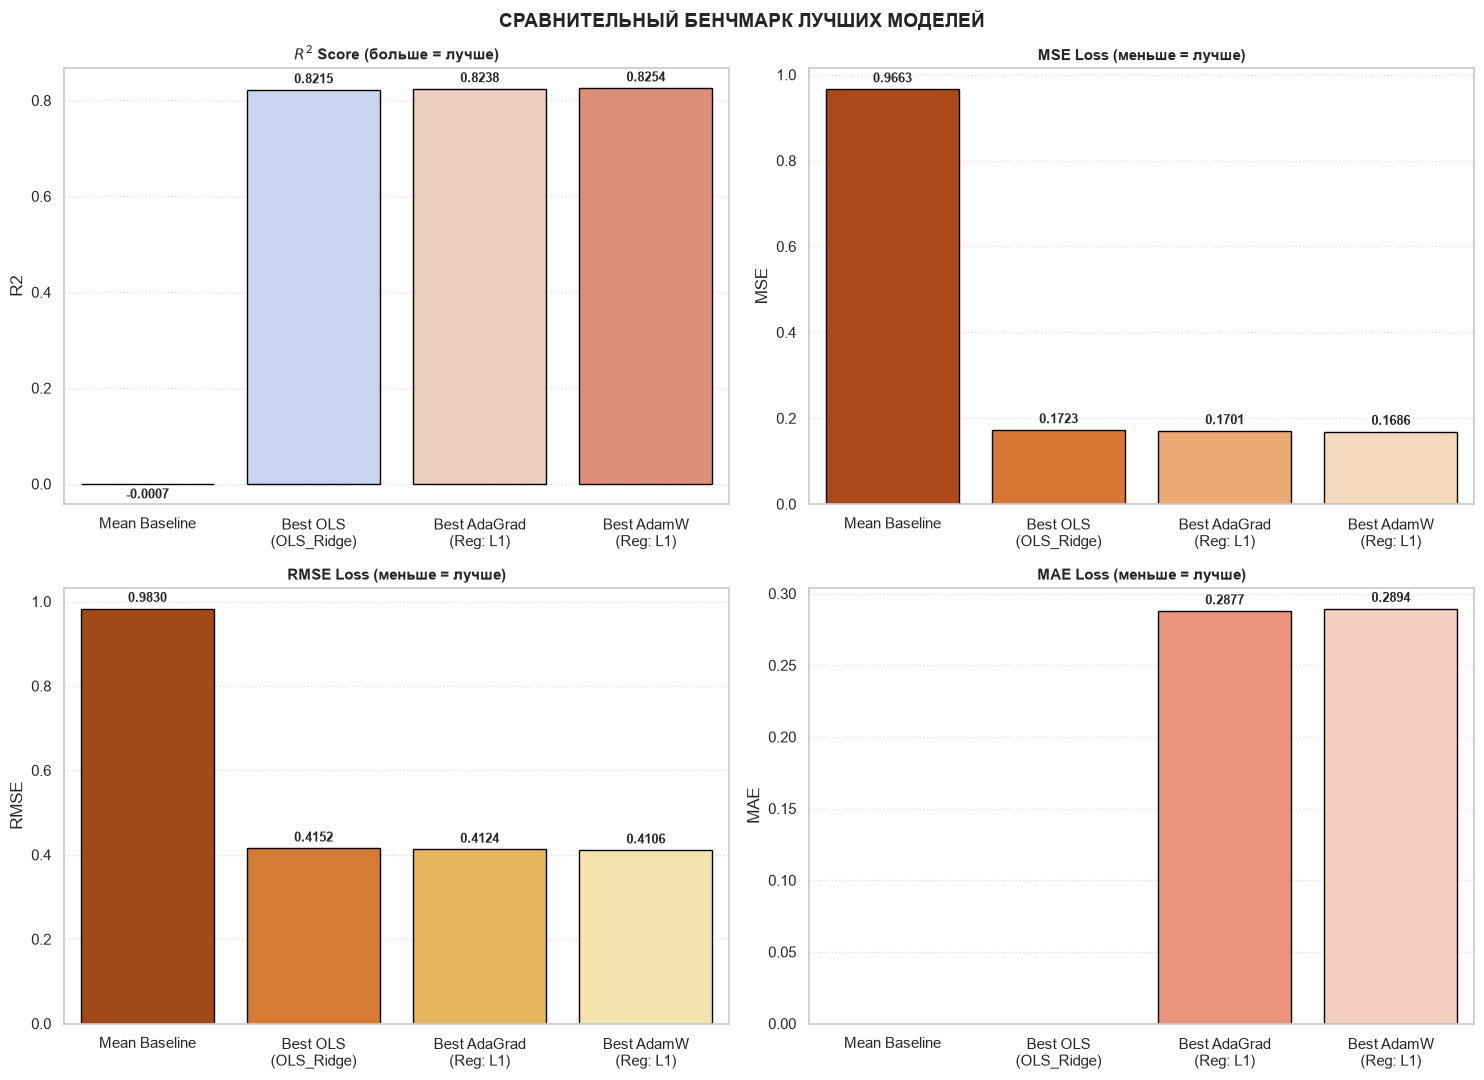

In [19]:
def get_best_nn_metrics(opt_name, reg_type):
    best_key = None
    min_mse = float("inf")
    for lr in CONFIG["LEARNING_RATES"]:
        for lmbda in CONFIG["LAMBDAS"]:
            if reg_type == "None" and lmbda != CONFIG["LAMBDAS"][0]:
                continue
            key = f"{opt_name}_{reg_type}_lr_{lr}_lambda_{lmbda:.4f}"
            if key in history_data and history_data[key]["best_mse"] < min_mse:
                min_mse = history_data[key]["best_mse"]
                best_key = key
                
    best_state = history_data[best_key]["best_state"]
    final_model = nn.Linear(INPUT_DIM, 1)
    final_model.load_state_dict(best_state)
    final_model.eval()
    with torch.no_grad():
        preds = final_model(X_test_tensor).numpy().flatten()
        weights = final_model.weight.numpy().flatten()
        
    y_test_scaled_flat = y_test_scaled.flatten()
    zeroed_weights = np.sum(np.abs(weights) < 1e-4)
    mse = mean_squared_error(y_test_scaled_flat, preds)
    return {
        "R2": r2_score(y_test_scaled_flat, preds),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test_scaled_flat, preds),
        "Sparsity": (zeroed_weights / len(weights)) * 100,
        "weights": weights,       
        "predictions": preds     
    }


final_comparison = {}
if "Mean_Baseline" in ols_metrics:
    final_comparison["Mean Baseline"] = ols_metrics["Mean_Baseline"].copy()
    if "RMSE" not in final_comparison["Mean Baseline"]:
        final_comparison["Mean Baseline"]["RMSE"] = np.sqrt(final_comparison["Mean Baseline"]["MSE"])

best_ols_key = locals().get('best_ols_model', 'OLS_Pure')
if best_ols_key in ols_metrics:
    final_comparison[f"Best OLS\n({best_ols_key})"] = ols_metrics[best_ols_key].copy()
    if "RMSE" not in final_comparison[f"Best OLS\n({best_ols_key})"]:
        final_comparison[f"Best OLS\n({best_ols_key})"]["RMSE"] = np.sqrt(ols_metrics[best_ols_key]["MSE"])

for opt in CONFIG["OPTIMIZERS"]:
    best_opt_metric = {"MSE": float("inf")}
    best_reg_name = "None"
    for reg in CONFIG["REG_TYPES"]:
        try:
            metrics = get_best_nn_metrics(opt, reg)
            if metrics["MSE"] < best_opt_metric["MSE"]:
                best_opt_metric = metrics
                best_reg_name = reg
        except Exception:
            continue
    final_comparison[f"Best {opt}\n(Reg: {best_reg_name})"] = best_opt_metric

scalar_comparison = {
    k: {metric: v[metric] for metric in ["R2", "MSE", "RMSE", "MAE", "Sparsity"] if metric in v}
    for k, v in final_comparison.items()
}
df_metrics = pd.DataFrame(scalar_comparison).T.reset_index().rename(columns={'index': 'Model'})

# Отрисовка метрик в сетке 2*2
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics_list = [
    ("R2", "$R^2$ Score (больше = лучше)", "coolwarm"),
    ("MSE", "MSE Loss (меньше = лучше)", "Oranges_r"),
    ("RMSE", "RMSE Loss (меньше = лучше)", "YlOrBr_r"),
    ("MAE", "MAE Loss (меньше = лучше)", "Reds_r")
]

for ax, (metric_col, title, palette) in zip(axes.flatten(), metrics_list):
    sns.barplot(data=df_metrics, x="Model", y=metric_col, hue="Model", palette=palette, edgecolor="black", legend=False, ax=ax)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(metric_col)
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3, fontweight='bold', fontsize=9)

plt.suptitle("СРАВНИТЕЛЬНЫЙ БЕНЧМАРК ЛУЧШИХ МОДЕЛЕЙ", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

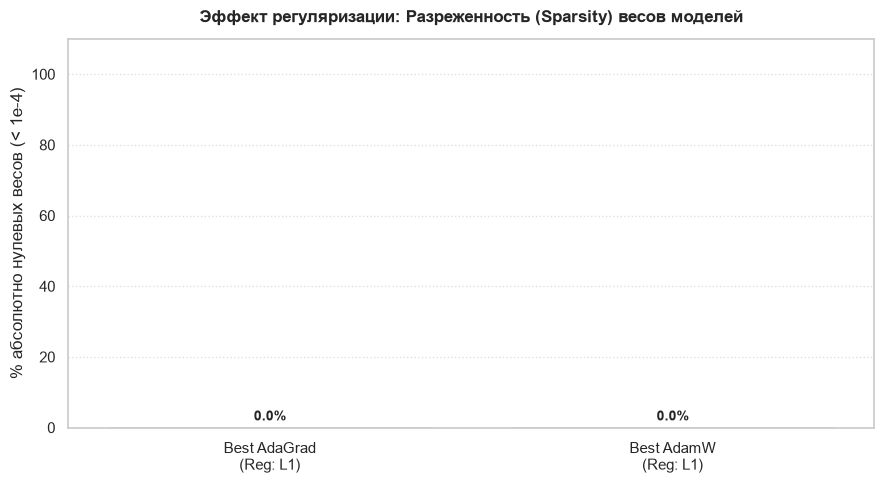


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ СТАТИСТИЧЕСКИЙ ОТЧЕТ ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Mean Baseline                       | R2: -0.0007 | MSE: 0.9663 | MAE: nan | Sparsity: Н/Д
Best OLS (OLS_Ridge)                | R2: 0.8215 | MSE: 0.1723 | MAE: nan | Sparsity: Н/Д
Best AdaGrad (Reg: L1)              | R2: 0.8238 | MSE: 0.1701 | MAE: 0.2877 | Sparsity: 0.0%
Best AdamW (Reg: L1)                | R2: 0.8254 | MSE: 0.1686 | MAE: 0.2894 | Sparsity: 0.0%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [20]:
plt.figure(figsize=(9, 5))
df_sparsity = df_metrics[df_metrics["Sparsity"].notna()]

ax = sns.barplot(
    data=df_sparsity, 
    x="Model", 
    y="Sparsity", 
    hue="Model",
    palette="viridis", 
    edgecolor="black", 
    legend=False
)

plt.title("Эффект регуляризации: Разреженность (Sparsity) весов моделей", fontweight='bold', fontsize=12, pad=12)
plt.ylabel("% абсолютно нулевых весов (< 1e-4)")
plt.xlabel("")
plt.ylim(0, 110)
plt.grid(axis='y', linestyle=':', alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "~"*30 + " СТАТИСТИЧЕСКИЙ ОТЧЕТ " + "~"*30)
for _, row in df_metrics.iterrows():
    sparsity_str = f"{row['Sparsity']:.1f}%" if pd.notna(row['Sparsity']) else "Н/Д"
    print(f"{row['Model'].replace('\n', ' '):<35} | R2: {row['R2']:.4f} | MSE: {row['MSE']:.4f} | MAE: {row['MAE']:.4f} | Sparsity: {sparsity_str}")
print("~"*92)

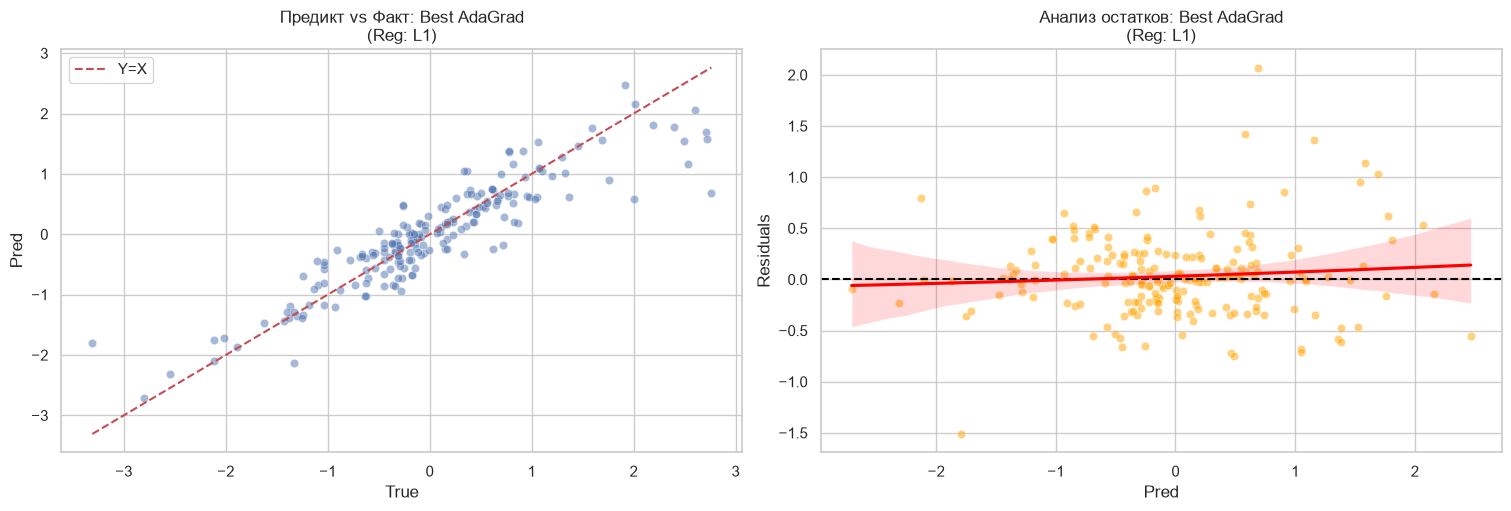

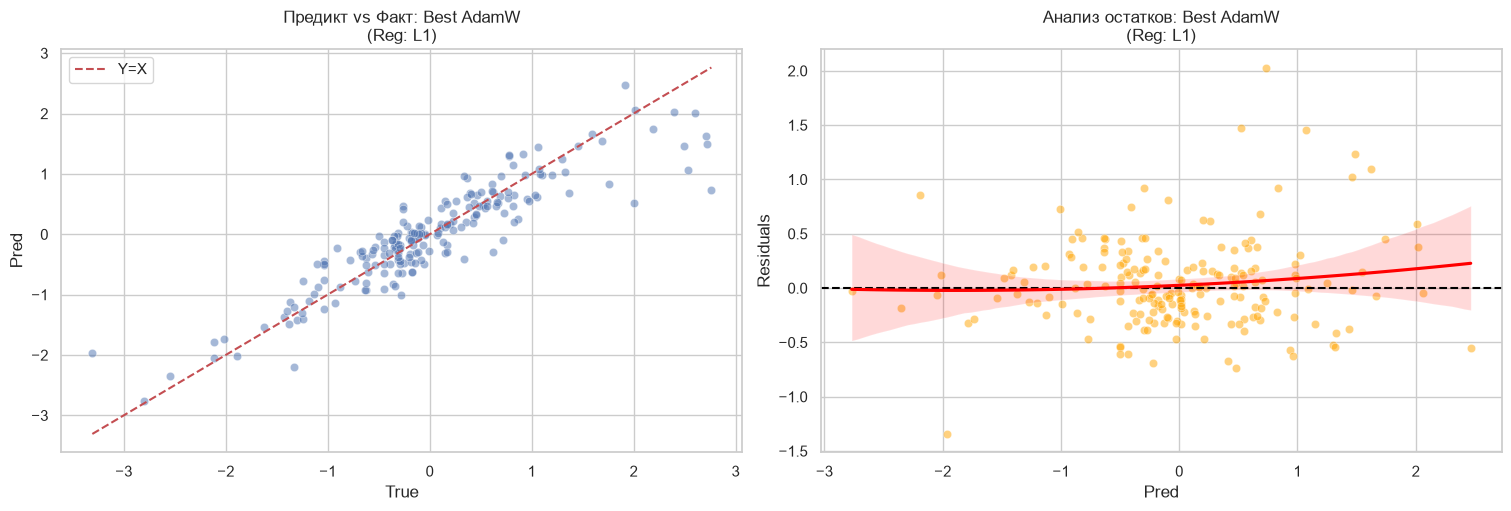

In [21]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~ГРАФИК 2 АНАЛИЗ ПРЕДСКАЗАНИЙ~~~~~~~~~~~~~~~~~~~~~~~~~~
y_test_true = y_test_scaled.flatten()

for key, data in final_comparison.items():
    if "predictions" not in data or "Mean Baseline" in key: continue
        
    preds = data["predictions"]
    res = y_test_true - preds
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    
    # Предикт vs Факт
    sns.scatterplot(x=y_test_true, y=preds, alpha=0.5, ax=ax1)
    ax1.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--', label='Y=X')
    ax1.set(title=f"Предикт vs Факт: {key}", xlabel="True", ylabel="Pred")
    ax1.legend()
    
    # Остатки
    sns.scatterplot(x=preds, y=res, color='orange', alpha=0.5, ax=ax2)
    ax2.axhline(0, color='black', linestyle='--')
    sns.regplot(x=preds, y=res, scatter=False, order=2, color='red', ax=ax2)
    ax2.set(title=f"Анализ остатков: {key}", xlabel="Pred", ylabel="Residuals")
    
    plt.show()

Лучшая конфигурация для AdaGrad: AdaGrad_L1_lr_0.1_lambda_0.0100 (Best Test MSE: 0.17010)
Лучшая конфигурация для AdamW: AdamW_L1_lr_0.05_lambda_0.0010 (Best Test MSE: 0.16861)


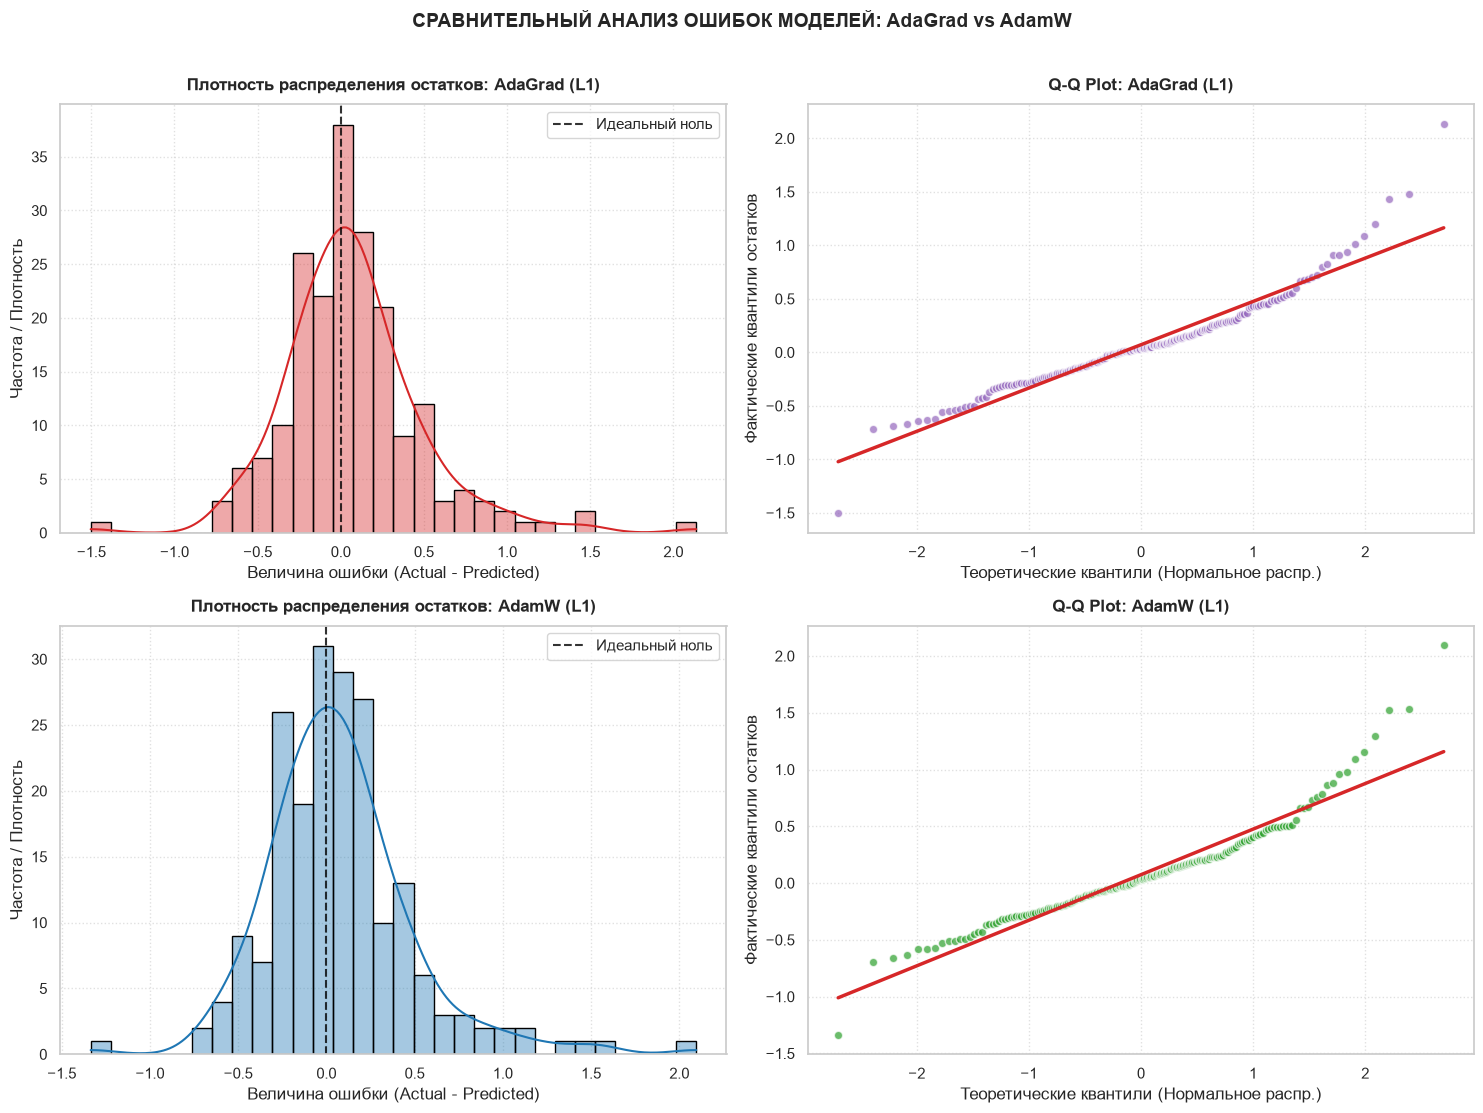

In [62]:
target_optimizers = ["AdaGrad", "AdamW"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for idx, target_opt in enumerate(target_optimizers):
    best_key = None
    min_mse = float("inf")
    
    for key, data in history_data.items():
        if data.get("opt") == target_opt:
            current_mse = data.get("best_mse") or data.get("best_val_mse") or data.get("final_test")
            if current_mse is not None and current_mse < min_mse:
                min_mse = current_mse
                best_key = key

    if best_key is None:
        print(f"В history_data не найдено конфигураций для {target_opt}")
        continue
        
    target_reg = history_data[best_key]["reg"]
    print(f"Лучшая конфигурация для {target_opt}: {best_key} (Best Test MSE: {min_mse:.5f})")

    best_state = history_data[best_key]["best_state"]
    final_model = nn.Linear(INPUT_DIM, 1)
    final_model.load_state_dict(best_state)
    final_model.eval()
    
    with torch.no_grad():
        preds = final_model(X_test_tensor).numpy().flatten()
        
    y_test_flat = y_test_scaled.flatten()
    residuals = y_test_flat - preds

    # оси для текущей строки (idx: 0 — AdaGrad, 1 — AdamW)
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]

    #~~~~~~~~~~~~~~~~~~~~~~~~~~ЛЕВЫЙ ГРАФИК: Распределение остатков~~~~~~~~~~~~~~~~~~~~~~~~~~
    color_theme = '#d62728' if target_opt == "AdaGrad" else '#1f77b4'
    
    sns.histplot(residuals, kde=True, color=color_theme, alpha=0.4, ax=ax1, bins=30, edgecolor='black')
    ax1.axvline(x=0, color='black', linestyle='--', alpha=0.8, linewidth=1.5, label='Идеальный ноль')
    ax1.set_title(f"Плотность распределения остатков: {target_opt} ({target_reg})", fontweight='bold', fontsize=12, pad=10)
    ax1.set_xlabel("Величина ошибки (Actual - Predicted)")
    ax1.set_ylabel("Частота / Плотность")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    #~~~~~~~~~~~~~~~~~~~~~~~~~~ПРАВЫЙ ГРАФИК: Q-Q Plot~~~~~~~~~~~~~~~~~~~~~~~~~~
    stats.probplot(residuals, dist="norm", plot=ax2)
    
    marker_color = '#9467bd' if target_opt == "AdaGrad" else '#2ca02c'
    ax2.get_lines()[0].set_markerfacecolor(marker_color)
    ax2.get_lines()[0].set_markeredgecolor('white')
    ax2.get_lines()[0].set_alpha(0.7)
    ax2.get_lines()[1].set_color('#d62728')
    ax2.get_lines()[1].set_linewidth(2.5)

    ax2.set_title(f"Q-Q Plot: {target_opt} ({target_reg})", fontweight='bold', fontsize=12, pad=10)
    ax2.set_xlabel("Теоретические квантили (Нормальное распр.)")
    ax2.set_ylabel("Фактические квантили остатков")
    ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ОШИБОК МОДЕЛЕЙ: AdaGrad vs AdamW", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ВЫВОДЫ

## Эмпирическое сравнение моделей и базовых решений
Анализ метрик на тестовой выборке позволяет выстроить иерархию качества предсказания моделей:

* Mean Baseline (Простое среднее): Обладает $R^2 \approx -0.0007$ и наивысшей ошибкой $MSE \approx 0.9663$. Это подтверждает, что тривиальное предсказание константы не имеет прогностической силы, а данные содержат выраженную структуру.
* Best OLS (Классический МНК / Ridge): Демонстрирует сильный результат для классического подхода ($MSE \approx 0.17235$, $R^2 \approx 0.8215$), выступая в качестве надежного ориентира.
* Best AdaGrad (с L1-регуляризацией): Показывет небольшое улучшение относительно классического МНК, снижая ошибку до $MSE \approx 0.17010$ и повышая долю объясненной дисперсии до $R^2 \approx 0.8238$.
* Best AdamW (с L1-регуляризацией): Является абсолютным лидером эксперимента. Модель достигла наименьшей ошибки $MSE \approx 0.16861$ и наивысшего коэффициента детерминации $R^2 \approx 0.8254$.

Итерационные градиентные методы (особенно AdamW), превзошли аналитическое решение МНК за счет более гибкого покоординатного подбора шагов и эффективного совмещения оптимизации с регуляризацией.

## Анализ влияния гиперпараметров и регуляризации
На основе двумерных тепловых карт (Heatmaps) и кривых обучения можно сделать следующие выводы о характере сходимости алгоритмов:

* Специфика AdaGrad: Лучшая конфигурация достигнута при достаточно высоком темпе обучения (lr = 0.1) и параметре штрафа lambda = 0.0100. Для AdaGrad критичен выбор более агрессивного стартового lr, поскольку алгоритм монотонно уменьшает эффективный шаг из-за накопления квадратов градиентов в знаменателе. При слишком малых lr (например, 0.001) модель быстро "застревает" и недообучается.
* Специфика AdamW: Оптимальный баланс найден при более мягком темпе обучения (lr = 0.05) и меньшем штрафе lambda = 0.0010. Механизм расцепленного спада весов (Decoupled Weight Decay) в сочетании с накоплением моментов (Momentum) обеспечивает AdamW плавную и стабильную сходимость без риска преждевременной остановки шага.
* Парадокс разреженности (Sparsity): Несмотря на то, что для обоих оптимизаторов наилучшим типом регуляризации на валидации была признана модификация L1 (Lasso), показатель разреженности весов составил 0.0% (ни один коэффициент не занулился строго ниже порога 1e-4). Это говорит о том, что L1-штраф сработал в данном случае не как жесткий селектор признаков, а как мягкий ограничитель их масштаба, предотвращающий переобучение, в то время как все 20 фичей сохранили свою информативность.

## Глубокий анализ графиков распределения ошибок (остатков)
Графики плотности остатков и квантильных диаграмм (Q-Q Plot) дают ключевое понимание характера ошибок лучших моделей:

* Плотность распределения остатков (Гистограммы + KDE):
* Графики как для AdaGrad, так и для AdamW центрированы практически идеально вокруг линии «Идеального нуля». Это указывает на отсутствие систематического смещения (bias) в предсказаниях — модели не склонны стабильно завышать или занижать целевую переменную.
* Кривая оценки плотности (KDE) имеет четкую колоколообразную форму, характерную для случайных величин, что подтверждает корректность использования линейной спецификации для данного набора данных. Основной паттерн данных успешно извлечен.

* Диаграммы (Q-Q Plots):
* В центральной области распределения (теоретические квантили от $-1.5$ до $+1.5$) фактические точки остатков обеих моделей лежат строго на красной опорной прямой линии. Это доказывает, что в подавляющем большинстве случаев случайные отклонения предсказаний подчиняются классическому нормальному закону распределения.
* Анализ хвостов: На крайних границах графиков (при теоретических квантилях менее $-2$ и более $+2$) наблюдается характерный S-образный изгиб: слева точки уходят ниже линии, а справа — выше нее. Этот визуальный паттерн однозначно указывает на эффект тяжелых хвостов (leptokurtic distribution). В выборке присутствуют аномалии и выбросы (outliers) — объекты, реальная цена которых существенно отличается от среднерыночной логики. В этих крайних точках линейная модель ошибается сильнее, чем ожидается при чистом нормальном распределении.


# Заключение
Эксперимент наглядно продемонстрировал преимущество современных градиентных методов над стандартными аналитическими бейзлайнами при подборе весов линейной регрессии. Модель AdamW с L1-регуляризацией показала наилучшую обобщающую способность ($R^2 = 82.54\%$). Анализ графиков остатков подтвердил высокое качество аппроксимации: ошибки ведут себя как белый шум на $90\%$ объектов, а зафиксированные отклонения на Q-Q Plot обусловлены, вероятно, наличием редких нелинейных выбросов в исходной выборке, для обработки которых в дальнейшем может потребоваться переход к нелинейным архитектурам или методам фильтрации аномалий.

In [23]:
class AdaGradLinearRegression:
    def __init__(self, learning_rate=0.1, epsilon=1e-8):
        self.lr = learning_rate
        self.epsilon = epsilon
        
        # параметры модели (инициализируются при первом запуске)
        self.w = None
        self.b = 0.0
        
        # история градиентов для AdaGrad
        self.G_w = None
        self.G_b = 0.0
        
        # mean и std, чтобы потом правильно нормализовать новые тестовые данные
        self.mean = None
        self.std = None

    def _normalize(self, X):
        """метод для ручной Z-score нормализации"""
        if self.mean is None or self.std is None:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
            # Защита от деления на 0
            self.std[self.std == 0] = 1e-8
        return (X - self.mean) / self.std

    def _get_gradient(self, X_scaled, y):
        """метод для ручного расчета градиентов на матрицах"""
        N = X_scaled.shape[0]
        # Прогноз: X * w + b
        predictions = np.dot(X_scaled, self.w) + self.b
        err = predictions - y
        
        # Матричное вычисление градиентов
        grad_w = (2 / N) * np.dot(X_scaled.T, err)
        grad_b = (2 / N) * np.sum(err)
        return grad_w, grad_b

    def __call__(self, X, y, epochs=500, verbose=True):
        """
        Этот метод вызывается в момент ' model(X, y) ',
        запускает полный цикл обучения
        """
        X_scaled = self._normalize(X)
        num_features = X.shape[1]
        # инициализация веса и истории AdaGrad нулями
        if self.w is None:
            self.w = np.zeros(num_features)
            self.G_w = np.zeros(num_features)
            self.G_b = 0.0

        for epoch in range(1, epochs + 1):
            grad_w, grad_b = self._get_gradient(X_scaled, y)
            
            self.G_w += grad_w  2
            self.G_b += grad_b  2
            
            self.w -= (self.lr / (np.sqrt(self.G_w) + self.epsilon)) * grad_w
            self.b -= (self.lr / (np.sqrt(self.G_b) + self.epsilon)) * grad_b
            
            # Логирование ошибки каждые 50 эпох
            if verbose and (epoch == 1 or epoch % 50 == 0):
                current_preds = np.dot(X_scaled, self.w) + self.b
                mse = np.mean((current_preds - y)  2)
                print(f"Эпоха {epoch:3d} | Текущая ошибка (MSE): {mse:.4f}")
        return self.w, self.b

    def predict(self, X):
        if self.w is None:
            raise ValueError("Нет ничего, что можно было бы предсказать")
        X_scaled = (X - self.mean) / self.std
        return np.dot(X_scaled, self.w) + self.b

In [24]:
np.random.seed(69)
X_random = np.random.rand(200, 19) * 100  # например, площади от 0 до 100 кв.м.

true_w = np.random.uniform(-5, 5, size=19)
true_b = 15.0
noise = np.random.normal(0, 2, size=200)
y_random = np.dot(X_random, true_w) + true_b + noise

adagrad_model = AdaGradLinearRegression(learning_rate=0.4, epsilon=1e-8)

print("--- Старт обучения ---")
final_w, final_b = adagrad_model(X_random, y_random, epochs=400)
print("--- Обучение завершено ---\n")

print(f"Истинный b: {true_b}")
print(f"Найденный b: {final_b:.4f}")

--- Старт обучения ---
Эпоха   1 | Текущая ошибка (MSE): 145235.6000
Эпоха  50 | Текущая ошибка (MSE): 131952.0373
Эпоха 100 | Текущая ошибка (MSE): 125768.9845
Эпоха 150 | Текущая ошибка (MSE): 121186.7397
Эпоха 200 | Текущая ошибка (MSE): 117430.4267
Эпоха 250 | Текущая ошибка (MSE): 114199.9234
Эпоха 300 | Текущая ошибка (MSE): 111341.7380
Эпоха 350 | Текущая ошибка (MSE): 108764.9399
Эпоха 400 | Текущая ошибка (MSE): 106410.3951
--- Обучение завершено ---

Истинный b: 15.0
Найденный b: 15.0283
